Korzystanie z narzędzi generatywnej AI w rozwiązywaniu zadań nie jest dozwolone

<img src="no_AI.png" alt="Use of AI allowed only when properly documented " width="100" height="100">

# Zadanie obowiązkowe [0-10] pkt

- Zapoznaj się z analizą zbioru [twarzy OLivetti](https://scikit-learn.org/stable/auto_examples/decomposition/plot_faces_decomposition.html)
- Zapoznaj się z ze zbiorem [klasyfikacji cyfr](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_digits.html)

1. [0-1 pkt] Załaduj zbiór cyfr, a następnie wyświetl pierwsze 6 (2 wiersze, 3 kolumny) elementów zbioru za pomocą funkcji `plot_gallery()` (zob. pierwszy link)
1. [0-0.5 pkt] Podziel zbiór na treningowy i walidacyjny (czy zbiór jest zbalansowany i wystarczy zwykły podział losowy?). Pamiętaj, że skalowanie cech jak i dostrojenie redukcji wymiarowości (metoda `fit`) przeprowadzamy na zbiorze treningowym!
1. [0-2.5 pkt] Dokonaj transformacji zbioru `digits` przy użyciu (w każdym przypadku wyrysuj kilka przykładowych elementów zbioru):
   1. PCA
   2. [NMF](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.NMF.html) (jaki będzie input?)
   3. [Factor Analysis](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.FactorAnalysis.html)
   4. [Jądrowy PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.KernelPCA.html) (przy użyciu przynajmniej trzech nieliniowych jąder)
2. [0-1.5 pkt] Wytrenuj regresję logistyczną na zbiorze oryginalnym (model *baseline*) oraz przetransformowanym za pomocą technik z punktu 3.
1. [0-1.5 pkt] Sporządź analizę porównawczą wyników zarówno dla zbioru treningowego jak i walidacyjnego. Wyrysuj macierz pomyłek oraz metryki zbiorcze
3. [0-1 pkt] Wybierz $n=32, 16, 8, 4, 2$ dominujące cechy w każdej metodzie i wykonaj analizę w pkt. 5.
1. [0-1 pkt] Skomentuj uzyskane wyniki. Czy redukcja wymiarowości jest optymalnym rozwiązaniem w przypadku tego zbioru? Jeśli tak, to która? Jeśli żadna, to dlaczego?
2. [0-1 pkt] Zaproponuj usprawnienie metodologii wyżej (np. inną technikę selekcji cech)

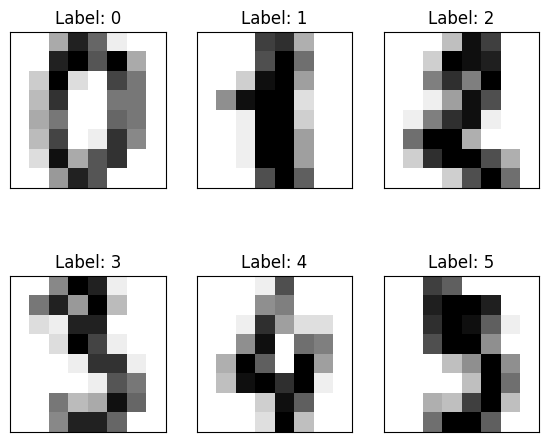

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits

digits = load_digits()
X = digits.images
y = digits.target

def plot_gallery(images, titles, h, w, n_row=2, n_col=3):
    plt.figure(figsize=(1.8 * n_col, 2.4 * n_row))
    plt.subplots_adjust(bottom=0, left=0.01, right=0.99, top=0.90, hspace=0.3)

    for i in range(n_row * n_col):
        plt.subplot(n_row, n_col, i + 1)
        plt.imshow(images[i], cmap=plt.cm.gray_r, interpolation="nearest")
        plt.title(f"Label: {titles[i]}")
        plt.xticks(())
        plt.yticks(())

plot_gallery(X, y, 8, 8)
plt.show()

W tym kroku wczytałem zbiór danych `digits` z biblioteki scikit-learn. Zbiór zawiera obrazy ręcznie pisanych cyfr (0-9), gdzie każdy obraz ma wymiar 8x8 pikseli. Następnie zwizualizowałem pierwsze 6 obrazów w układzie 2x3, aby zapoznać się z danymi. Użyłem funkcji `plot_gallery`, która pozwala szybko porównać wiele obrazów jednocześnie

In [2]:
from sklearn.model_selection import train_test_split
import numpy as np

X_flat = X.reshape((X.shape[0], -1))

unique, counts = np.unique(y, return_counts=True)
print("Rozkład klas:", dict(zip(unique, counts)))

X_train, X_test, y_train, y_test = train_test_split(
    X_flat, y, test_size=0.25, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Rozkład klas: {np.int64(0): np.int64(178), np.int64(1): np.int64(182), np.int64(2): np.int64(177), np.int64(3): np.int64(183), np.int64(4): np.int64(181), np.int64(5): np.int64(182), np.int64(6): np.int64(181), np.int64(7): np.int64(179), np.int64(8): np.int64(174), np.int64(9): np.int64(180)}
Train size: (1347, 64)
Test size: (450, 64)


Sprawdzamy czy dane są zbalansowane oraz dzielimy zbiór na część treningową i testową. Widzimy, że zbiór ten jest zbalansowany, bo każda cyfra występuje podobną liczbę razy, dlatego możemy zastosować zwykły, losowy podział danych.

W kolejnym kroku zastosuję różne techniki redukcji wymiarowości i ekstrakcji cech w celu porównania jak różne metody reprezentują dane obrazy cyfr oraz jak wpływają na ich strukturę:

- PCA
- NMF
- Factor Analysis
- Kernel PCA

In [5]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA, NMF, FactorAnalysis, KernelPCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import numpy as np

def plot_reconstructed(images, n=6, title=""):
    plt.figure(figsize=(8, 3))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        plt.imshow(images[i].reshape(8, 8), cmap="gray")
        plt.axis("off")
    plt.suptitle(title)
    plt.show()

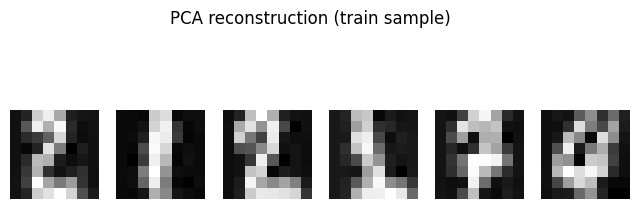

In [6]:
pca = PCA(n_components=30, random_state=42)
X_pca = pca.fit_transform(X_train)
X_pca_inv = pca.inverse_transform(X_pca)

plot_reconstructed(X_pca_inv, title="PCA reconstruction (train sample)")

PCA redukuje wymiarowość poprzez projekcję danych na główne składowe maksymalizujące wariancję.

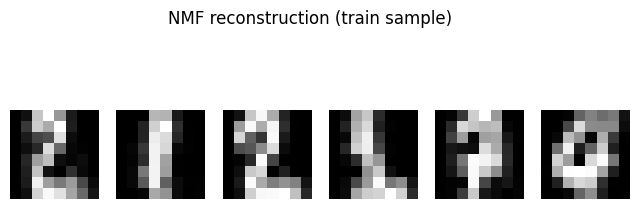

In [7]:
nmf = NMF(n_components=30, init="nndsvda", random_state=42, max_iter=500)
X_nmf = nmf.fit_transform(X_train)
X_nmf_inv = nmf.inverse_transform(X_nmf)

plot_reconstructed(X_nmf_inv, title="NMF reconstruction (train sample)")

NMF działa tylko na danych nieujemnych, dlatego wejściem są oryginalne piksele (bez standaryzacji z ujemnymi wartościami).

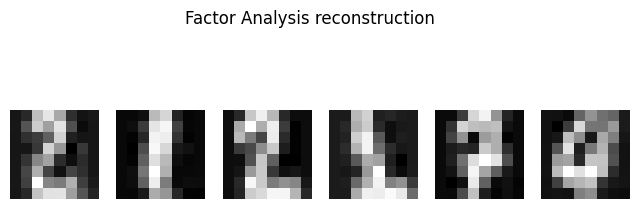

In [8]:
fa = FactorAnalysis(n_components=30, random_state=42)
X_fa = fa.fit_transform(X_train)
X_fa_inv = np.dot(X_fa, fa.components_) + fa.mean_

plot_reconstructed(X_fa_inv, title="Factor Analysis reconstruction")

Factor Analysis modeluje dane jako kombinację ukrytych czynników i szumu Gaussowskiego.

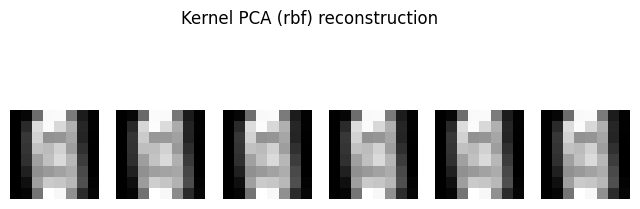

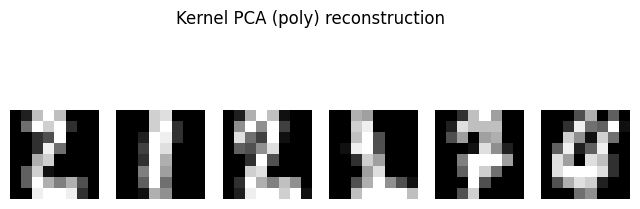

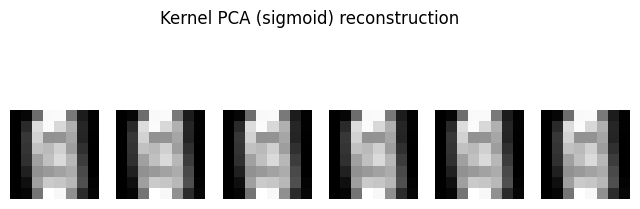

In [9]:
kernels = ["rbf", "poly", "sigmoid"]

for k in kernels:
    kpca = KernelPCA(n_components=30, kernel=k, fit_inverse_transform=True, random_state=42)
    X_kpca = kpca.fit_transform(X_train)
    X_kpca_inv = kpca.inverse_transform(X_kpca)

    plot_reconstructed(X_kpca_inv, title=f"Kernel PCA ({k}) reconstruction")

Kernel PCA pozwala na nieliniową redukcję wymiarowości dzięki zastosowaniu funkcji jądra.

Przetestowałem różne jądra: RBF, poly, sigmoid. Kernel PCA z jądrami RBF i sigmoid daje rozmyte rekonstrukcje, ponieważ metoda ta nie posiada dokładnej odwrotności transformacji. Rekonstrukcja danych odbywa się poprzez aproksymację w przestrzeni wejściowej, co prowadzi do utraty szczegółów obrazu.

In [10]:
def train_eval(X_train_t, X_test_t, y_train, y_test, name="model"):
    clf = LogisticRegression(max_iter=2000, solver="lbfgs")
    clf.fit(X_train_t, y_train)
    preds = clf.predict(X_test_t)
    acc = accuracy_score(y_test, preds)
    print(f"{name} accuracy: {acc:.4f}")
    return acc

baseline_model = LogisticRegression(max_iter=2000, solver="lbfgs")
baseline_model.fit(X_train, y_train)
baseline_preds = baseline_model.predict(X_test)
baseline_acc = accuracy_score(y_test, baseline_preds)

print("Baseline accuracy:", baseline_acc)

pca = PCA(n_components=30, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

train_eval(X_train_pca, X_test_pca, y_train, y_test, "PCA")

nmf = NMF(n_components=30, init="nndsvda", random_state=42, max_iter=500)
X_train_nmf = nmf.fit_transform(X_train)
X_test_nmf = nmf.transform(X_test)

train_eval(X_train_nmf, X_test_nmf, y_train, y_test, "NMF")

fa = FactorAnalysis(n_components=30, random_state=42)
X_train_fa = fa.fit_transform(X_train)
X_test_fa = fa.transform(X_test)

train_eval(X_train_fa, X_test_fa, y_train, y_test, "Factor Analysis")

for k in ["rbf", "poly", "sigmoid"]:
    kpca = KernelPCA(n_components=30, kernel=k, fit_inverse_transform=False, random_state=42)
    
    X_train_kpca = kpca.fit_transform(X_train)
    X_test_kpca = kpca.transform(X_test)
    
    train_eval(X_train_kpca, X_test_kpca, y_train, y_test, f"Kernel PCA ({k})")

Baseline accuracy: 0.96
PCA accuracy: 0.9578
NMF accuracy: 0.7689
Factor Analysis accuracy: 0.9600
Kernel PCA (rbf) accuracy: 0.2600
Kernel PCA (poly) accuracy: 0.9578
Kernel PCA (sigmoid) accuracy: 0.1022


W tym kroku trenuję model baseline na oryginalnych danych oraz porównujemy wyniki z danymi przekształconymi różnymi metodami redukcji wymiarowości w celu sprawdzenia, czy transformacje poprawiają, czy pogarszają jakość klasyfikacji.


Baseline
Train accuracy: 1.0000
Test accuracy:  0.9600


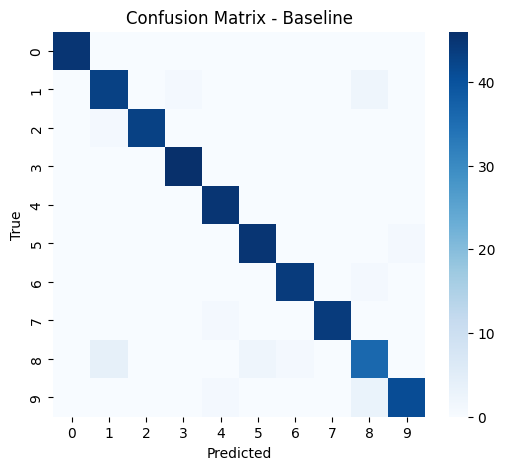


PCA
Train accuracy: 1.0000
Test accuracy:  0.9578


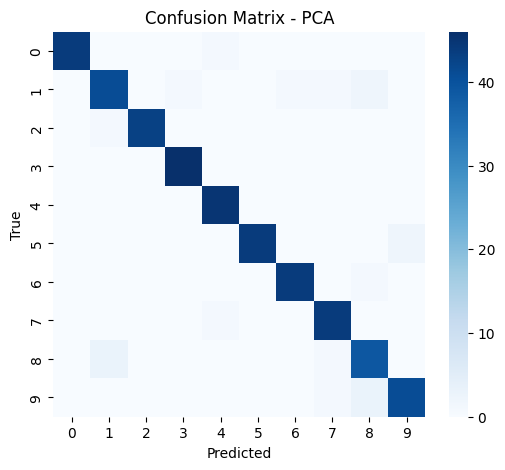


NMF
Train accuracy: 0.7944
Test accuracy:  0.7689


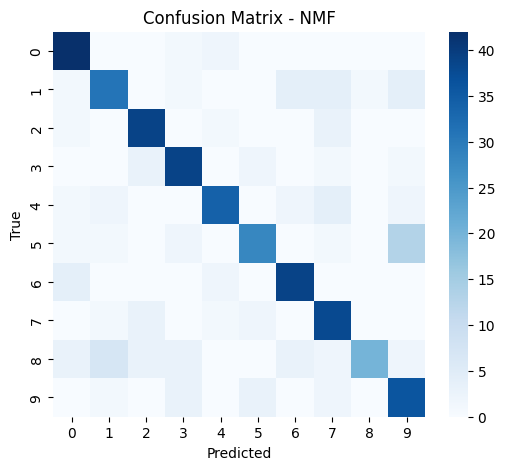


Factor Analysis
Train accuracy: 0.9933
Test accuracy:  0.9600


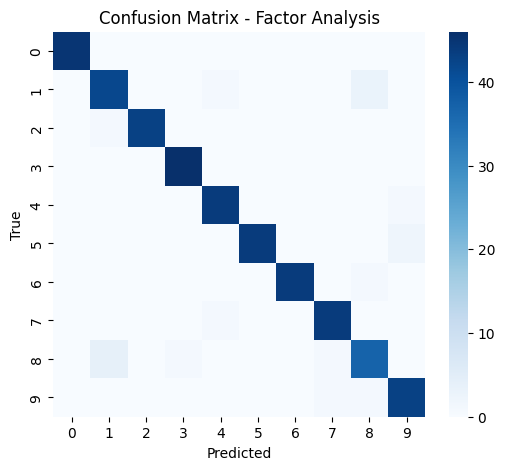


KPCA-rbf
Train accuracy: 0.3771
Test accuracy:  0.2600


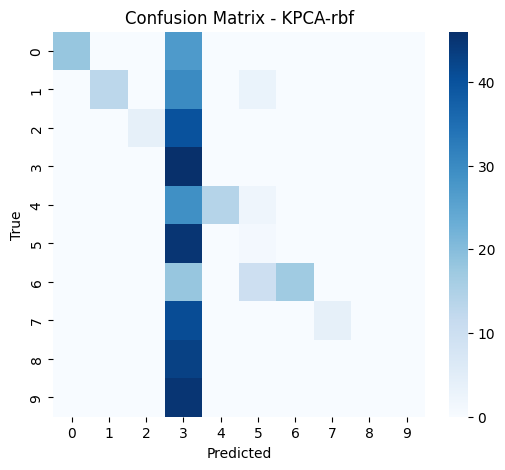


KPCA-poly
Train accuracy: 1.0000
Test accuracy:  0.9578


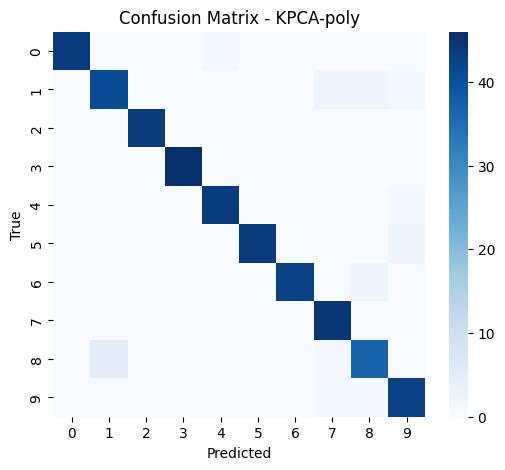


KPCA-sigmoid
Train accuracy: 0.1017
Test accuracy:  0.1022


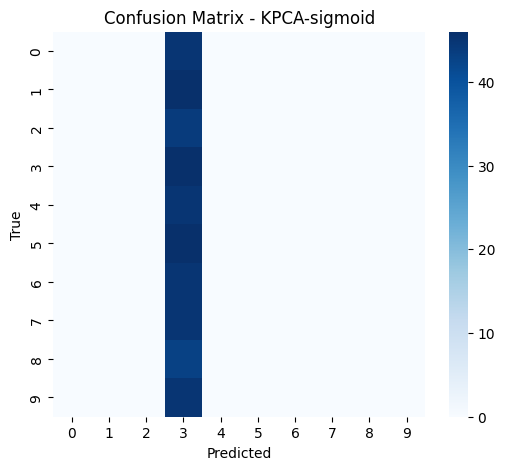

In [11]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

def evaluate_model(name, model, X_train_t, X_test_t):
    y_train_pred = model.predict(X_train_t)
    y_test_pred = model.predict(X_test_t)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    print(f"\n{name}")
    print(f"Train accuracy: {train_acc:.4f}")
    print(f"Test accuracy:  {test_acc:.4f}")

    cm = confusion_matrix(y_test, y_test_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=False, cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    return train_acc, test_acc

baseline = LogisticRegression(max_iter=2000, solver="lbfgs")
baseline.fit(X_train, y_train)

baseline_train, baseline_test = evaluate_model(
    "Baseline",
    baseline,
    X_train,
    X_test
)

results = {}

# PCA
pca = PCA(n_components=30, random_state=42)
Xtr = pca.fit_transform(X_train)
Xte = pca.transform(X_test)

model = LogisticRegression(max_iter=2000)
model.fit(Xtr, y_train)
results["PCA"] = evaluate_model("PCA", model, Xtr, Xte)

# NMF
nmf = NMF(n_components=30, init="nndsvda", random_state=42, max_iter=500)
Xtr = nmf.fit_transform(X_train)
Xte = nmf.transform(X_test)

model = LogisticRegression(max_iter=2000)
model.fit(Xtr, y_train)
results["NMF"] = evaluate_model("NMF", model, Xtr, Xte)

# FA
fa = FactorAnalysis(n_components=30, random_state=42)
Xtr = fa.fit_transform(X_train)
Xte = fa.transform(X_test)

model = LogisticRegression(max_iter=2000)
model.fit(Xtr, y_train)
results["FA"] = evaluate_model("Factor Analysis", model, Xtr, Xte)

# KPCA
for k in ["rbf", "poly", "sigmoid"]:
    kpca = KernelPCA(n_components=30, kernel=k, random_state=42)

    Xtr = kpca.fit_transform(X_train)
    Xte = kpca.transform(X_test)

    model = LogisticRegression(max_iter=2000)
    model.fit(Xtr, y_train)

    results[f"KPCA-{k}"] = evaluate_model(f"KPCA-{k}", model, Xtr, Xte)

W tym kroku porównałem skuteczność klasyfikacji dla danych oryginalnych i danych po redukcji wymiarowości. Przygotowałem zestawienie accuracy na zbiorze treningowym i testowym, macierz pomyłek dla każdej z metod

W następnym kroku zbadam jak liczba cech wpływa na jakość klasyfikacji. Sprawdzę wartości n = 32, 16, 8, 4, 2 dla każdej metody redukcji wymiarowości.


PCA

PCA n=32
Train accuracy: 1.0000
Test accuracy:  0.9600


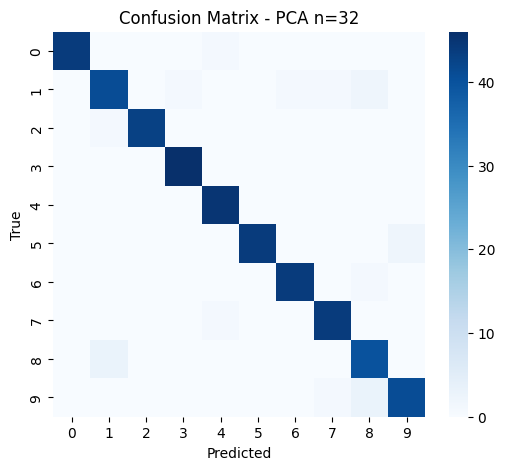


PCA n=16
Train accuracy: 0.9896
Test accuracy:  0.9244


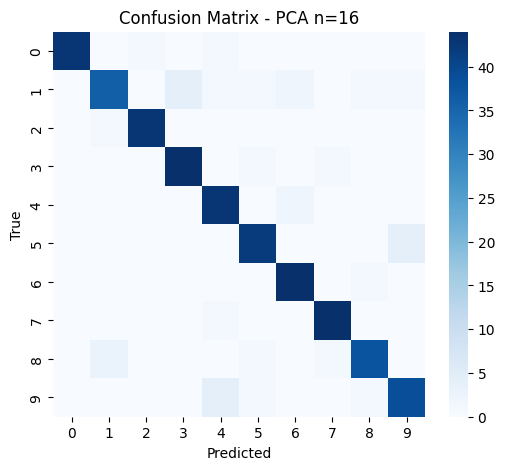


PCA n=8
Train accuracy: 0.9183
Test accuracy:  0.9067


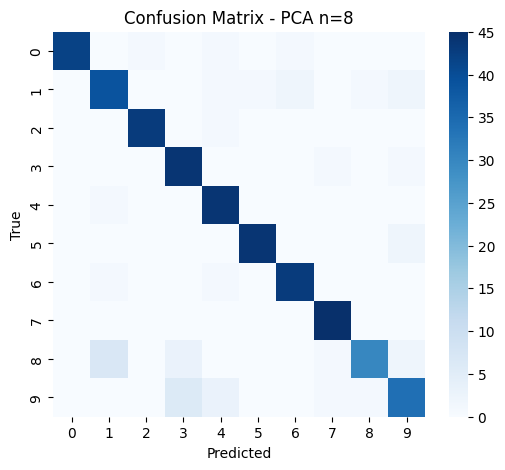


PCA n=4
Train accuracy: 0.8255
Test accuracy:  0.7844


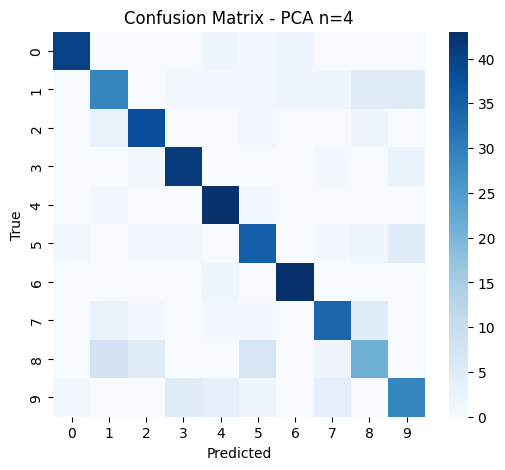


PCA n=2
Train accuracy: 0.6169
Test accuracy:  0.5911


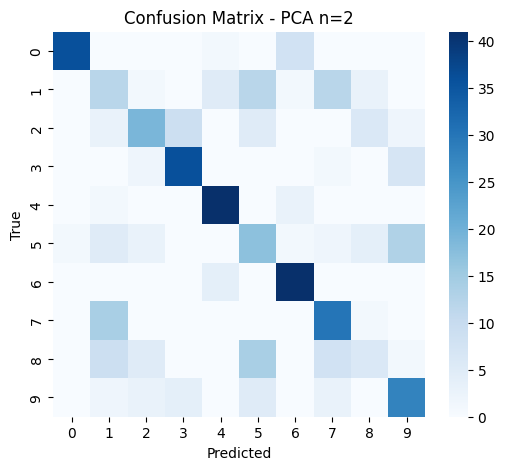


NMF

NMF n=32
Train accuracy: 0.7268
Test accuracy:  0.7467


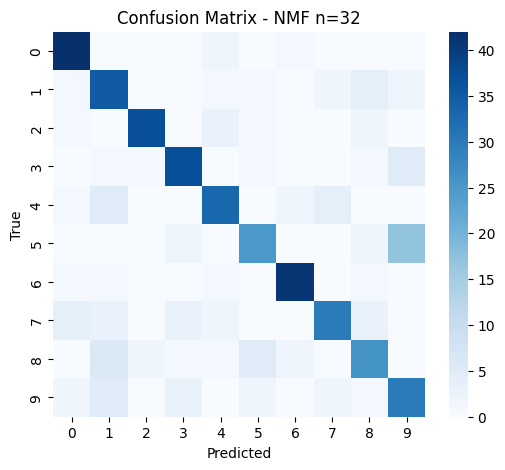


NMF n=16
Train accuracy: 0.7914
Test accuracy:  0.8022


C:\Users\Kubul\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\decomposition\_nmf.py:1728: ConvergenceWarning: Maximum number of iterations 500 reached. Increase it to improve convergence.
  warnings.warn(


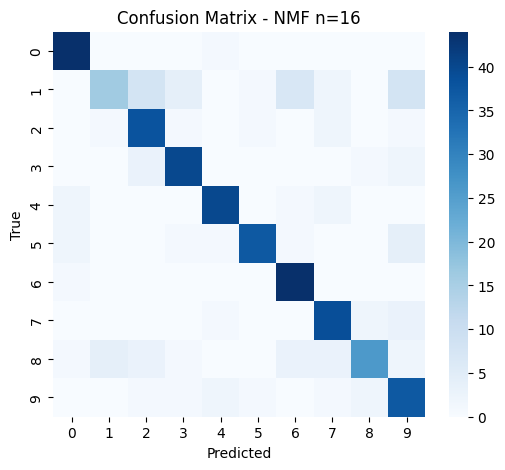


NMF n=8
Train accuracy: 0.7171
Test accuracy:  0.7267


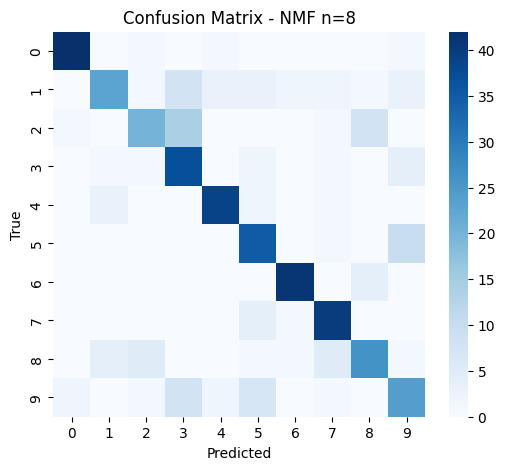


NMF n=4
Train accuracy: 0.6837
Test accuracy:  0.6733


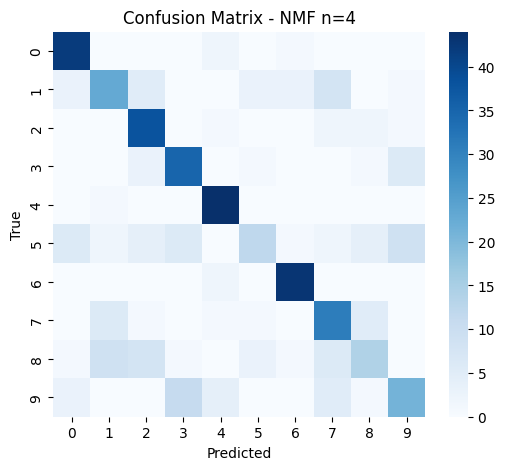


NMF n=2
Train accuracy: 0.3979
Test accuracy:  0.3822


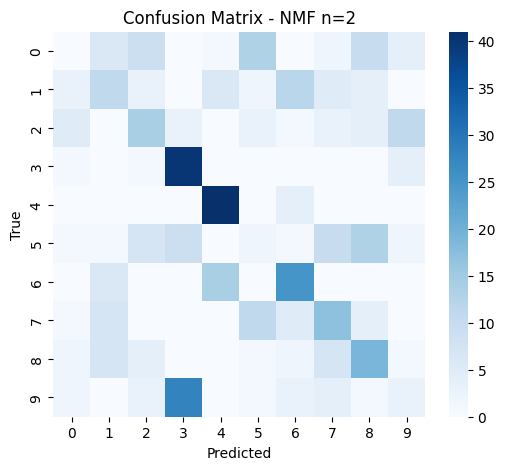


FA

FA n=32
Train accuracy: 0.9926
Test accuracy:  0.9578


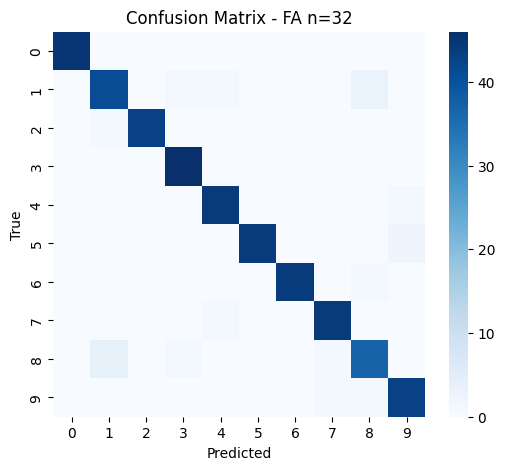


FA n=16
Train accuracy: 0.9651
Test accuracy:  0.9289


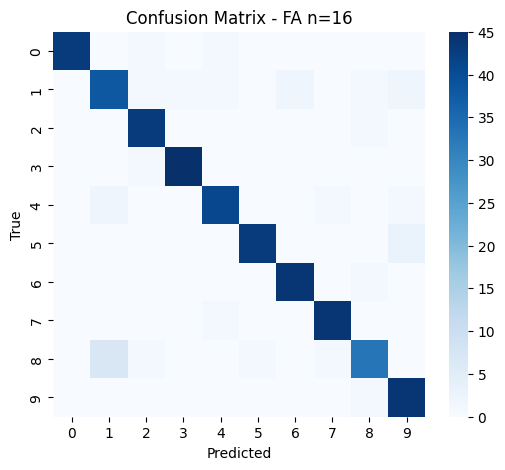


FA n=8
Train accuracy: 0.8671
Test accuracy:  0.8422


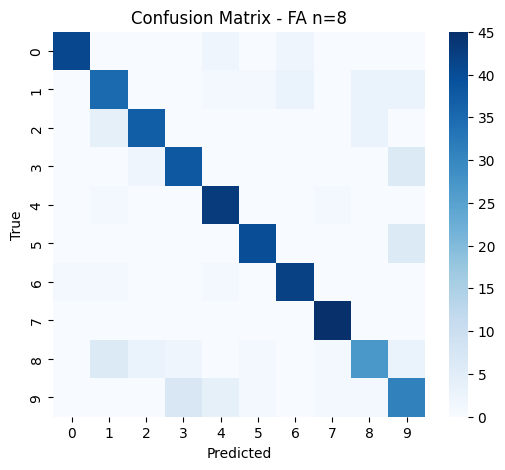


FA n=4
Train accuracy: 0.7840
Test accuracy:  0.7378


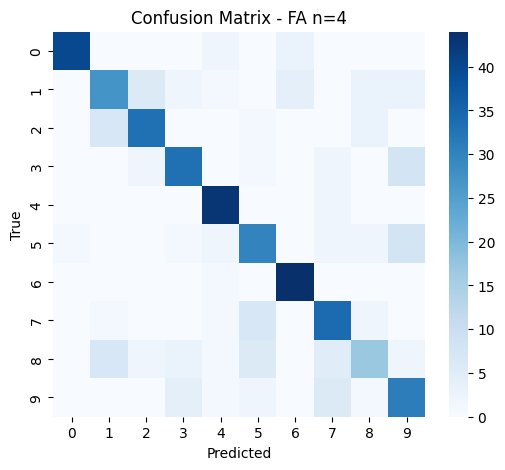


FA n=2
Train accuracy: 0.4803
Test accuracy:  0.4578


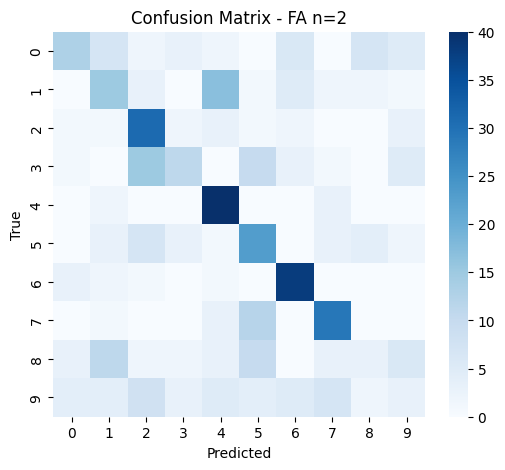


KPCA-rbf

KPCA-rbf n=32
Train accuracy: 0.4016
Test accuracy:  0.2622


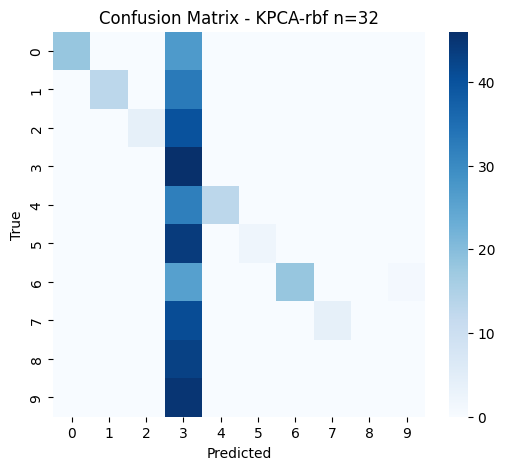


KPCA-rbf n=16
Train accuracy: 0.2762
Test accuracy:  0.2200


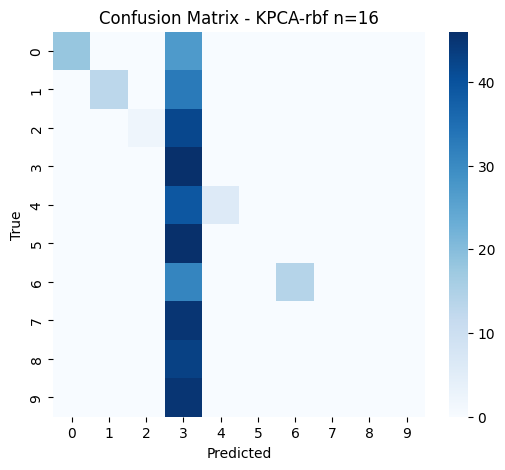


KPCA-rbf n=8
Train accuracy: 0.2294
Test accuracy:  0.2000


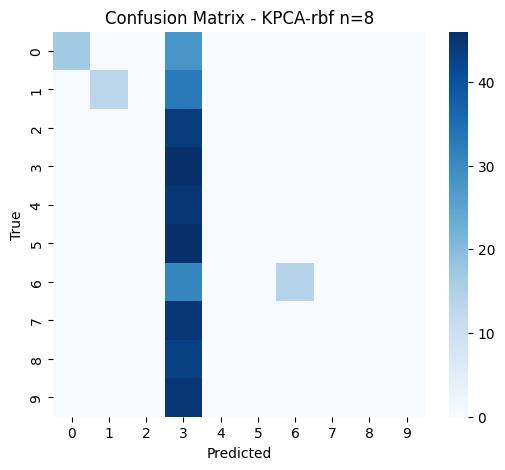


KPCA-rbf n=4
Train accuracy: 0.2183
Test accuracy:  0.1867


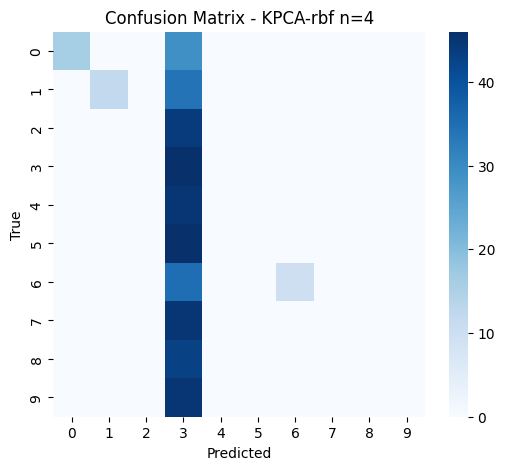


KPCA-rbf n=2
Train accuracy: 0.1262
Test accuracy:  0.1289


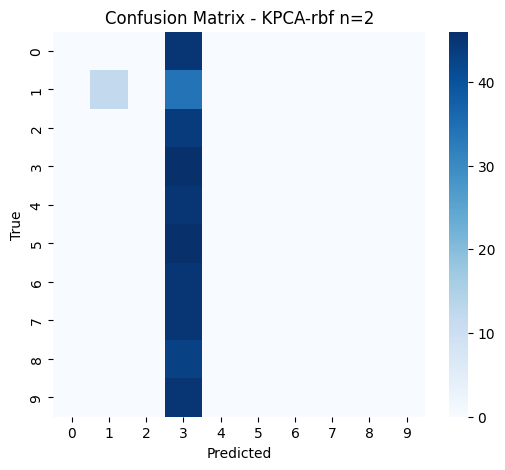


KPCA-poly

KPCA-poly n=32
Train accuracy: 1.0000
Test accuracy:  0.9556


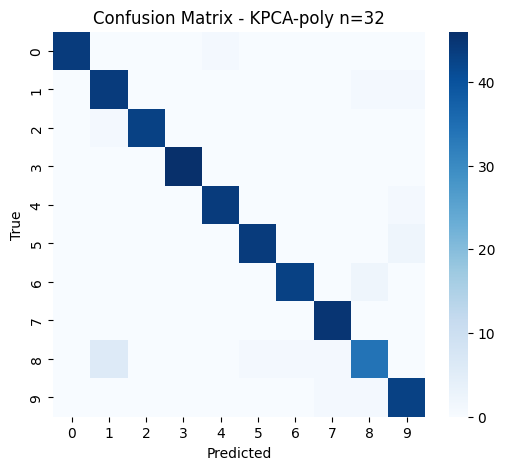


KPCA-poly n=16
Train accuracy: 1.0000
Test accuracy:  0.9289


C:\Users\Kubul\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


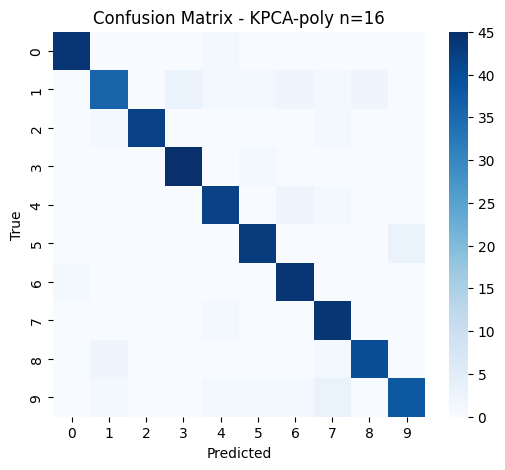


KPCA-poly n=8
Train accuracy: 0.9183
Test accuracy:  0.8867


C:\Users\Kubul\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


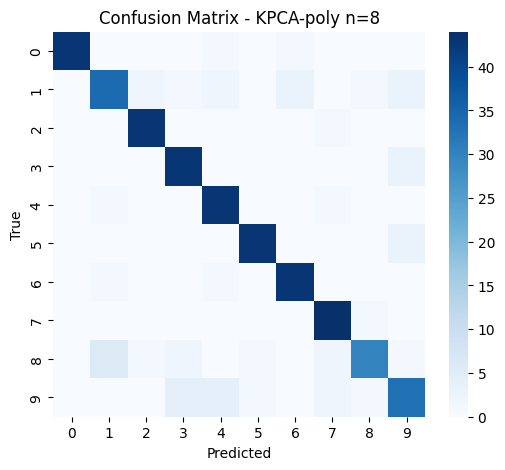


KPCA-poly n=4
Train accuracy: 0.7854
Test accuracy:  0.7578


C:\Users\Kubul\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


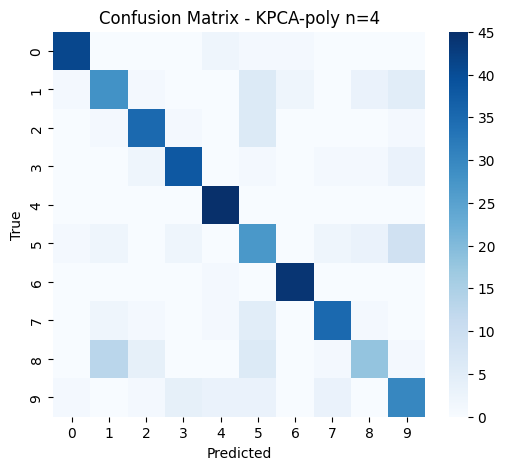


KPCA-poly n=2
Train accuracy: 0.5672
Test accuracy:  0.5978


C:\Users\Kubul\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


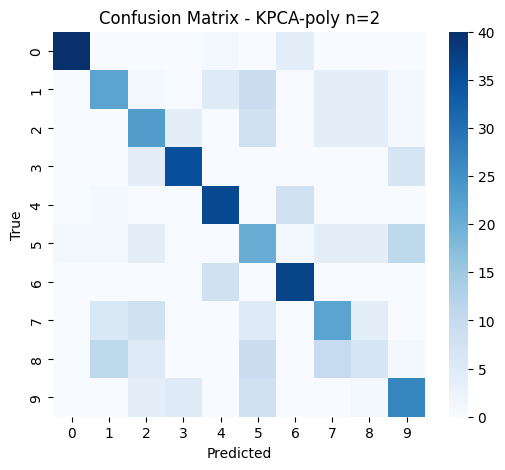


KPCA-sigmoid

KPCA-sigmoid n=32
Train accuracy: 0.1017
Test accuracy:  0.1022


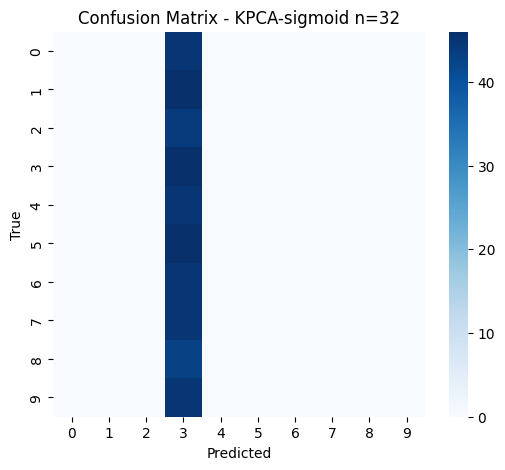


KPCA-sigmoid n=16
Train accuracy: 0.1017
Test accuracy:  0.1022


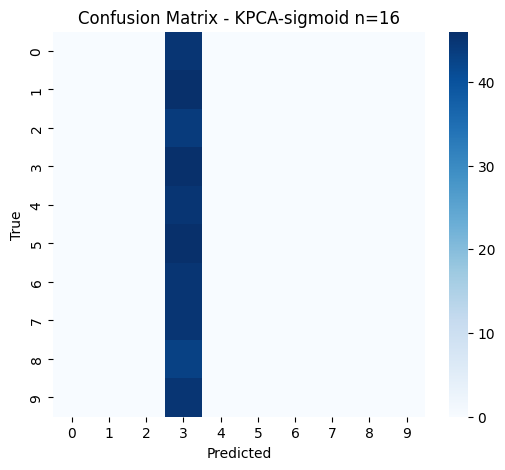


KPCA-sigmoid n=8
Train accuracy: 0.1017
Test accuracy:  0.1022


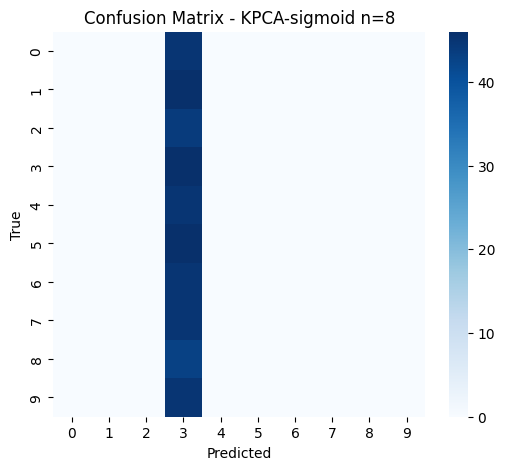


KPCA-sigmoid n=4
Train accuracy: 0.1017
Test accuracy:  0.1022


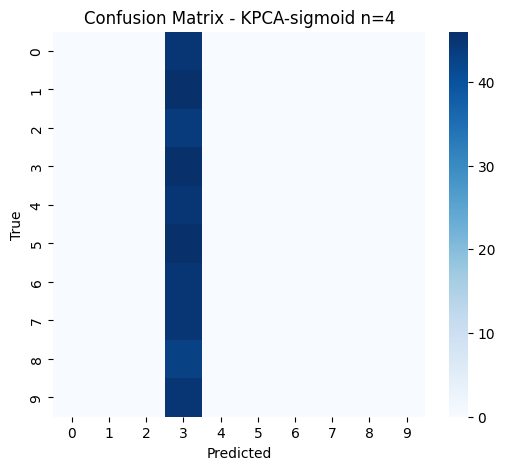


KPCA-sigmoid n=2
Train accuracy: 0.1017
Test accuracy:  0.1022


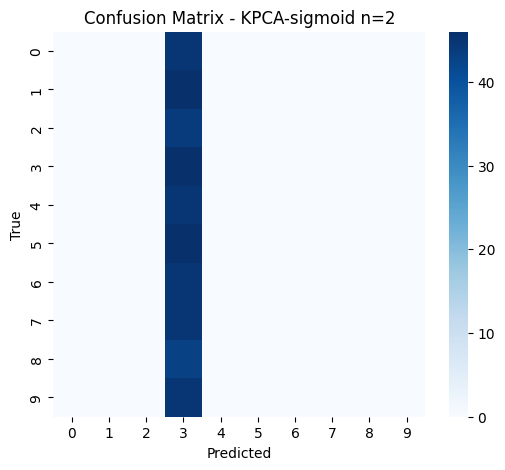

In [13]:
components = [32, 16, 8, 4, 2]

methods = {
    "PCA": lambda n: PCA(n_components=n, random_state=42),

    "NMF": lambda n: NMF(
        n_components=n,
        init="nndsvda",
        random_state=42,
        max_iter=500
    ),

    "FA": lambda n: FactorAnalysis(
        n_components=n,
        random_state=42
    ),

    "KPCA-rbf": lambda n: KernelPCA(
        n_components=n,
        kernel="rbf",
        random_state=42
    ),

    "KPCA-poly": lambda n: KernelPCA(
        n_components=n,
        kernel="poly",
        random_state=42
    ),

    "KPCA-sigmoid": lambda n: KernelPCA(
        n_components=n,
        kernel="sigmoid",
        random_state=42
    )
}

all_results = {}

for method_name, transformer_factory in methods.items():

    scores = []

    print(f"\n{'=' * 50}")
    print(method_name)
    print(f"{'=' * 50}")

    for n in components:

        transformer = transformer_factory(n)

        Xtr = transformer.fit_transform(X_train)
        Xte = transformer.transform(X_test)

        model = LogisticRegression(max_iter=2000)

        model.fit(Xtr, y_train)

        train_acc, test_acc = evaluate_model(
            f"{method_name} n={n}",
            model,
            Xtr,
            Xte
        )

        scores.append((n, train_acc, test_acc))

    all_results[method_name] = scores

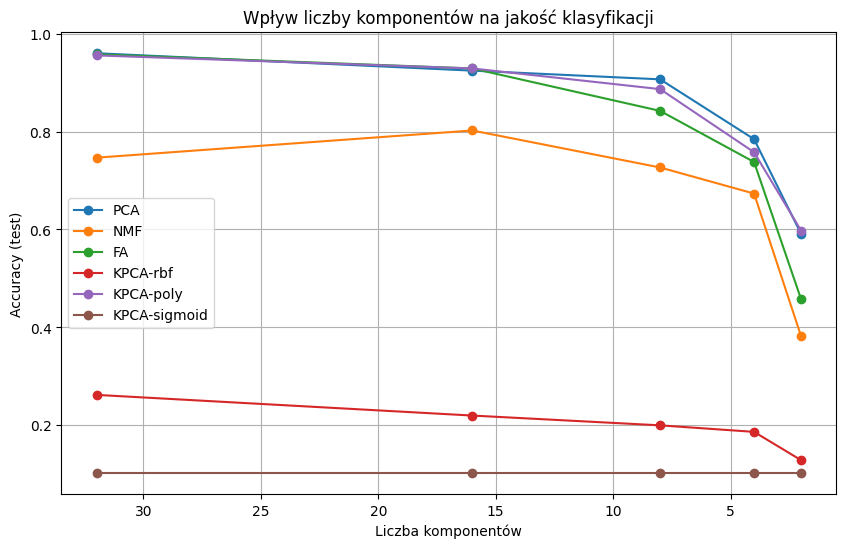

In [14]:
plt.figure(figsize=(10, 6))

for method_name, scores in all_results.items():

    n_vals = [x[0] for x in scores]
    test_vals = [x[2] for x in scores]

    plt.plot(
        n_vals,
        test_vals,
        marker="o",
        label=method_name
    )

plt.gca().invert_xaxis()

plt.xlabel("Liczba komponentów")
plt.ylabel("Accuracy (test)")
plt.title("Wpływ liczby komponentów na jakość klasyfikacji")
plt.legend()
plt.grid(True)

plt.show()

W analizowanym przypadku redukcja wymiarowości nie przynosi poprawy jakości klasyfikacji w stosunku do bazowej liczby cech (32). Wraz ze spadkiem liczby komponentów, accuracy na zbiorze testowym dla większości algorytmów sukcesywnie maleje, a poniżej 8 komponentów następuje gwałtowne załamanie wydajności. Dla NMF dokładność rośnie z poziomu ok. 0.75 dla 32 komponentów do ok. 0.8 dla 16 komponentów. Jednakże, wynik NMF jest drastycznie gorszy od metod bazujących na pełnym zbiorze cech, gdzie PCA oraz KPCA-poly startują z najwyższego pułapu ok. 0.96. Redukcja wymiarowości za pomocą testowanych metod ekstrakcji cech nie jest więc optymalnym rozwiązaniem dla tego zbioru danych, ponieważ usuwanie komponentów powoduje bezpowrotną utratę informacji istotnych dla klasyfikatora. Najlepszą strategią zachowania wysokiej jakości jest pozostanie przy pełnym zestawie cech wyjściowych (32) przy użyciu standardowego PCA lub liniowego/wielomianowego przekształcenia.

W celu poprawy wyników warto zmodyfikować podejście i można zastosować następujące usprawnienia: przejście z ekstrakcji na selekcję cech (dobrym wyborem mogą być techniki wbudowane, takie jak regularyzacja Lasso (L1) lub drzewa decyzyjne) czy zastosowanie metod algorytmicznych, takich jak wdrożenie procedury RFE w połączeniu z docelowym klasyfikatorem.

# Zadanie dodatkowe [0-4] pkt

1. [0-3 pkt] Dokonaj redukcji wymiarowości za pomocą trzech wybranych metod nieliniowych ze zbioru: t-SNE, UMAP, TriMAP, PaCMAP, a następnie użyj tak przetransformowanego zbioru w naszym problemie klasyfikacji cyfr
2. [0-1 pkt] Czy użycie tych zaawansowanych technik ma sens w tym przypadku?

In [16]:
from sklearn.manifold import TSNE
import umap
import pacmap

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

C:\Users\Kubul\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [17]:
umap_model = umap.UMAP(n_components=32, random_state=42)

X_train_umap = umap_model.fit_transform(X_train, y_train)
X_test_umap = umap_model.transform(X_test)

clf_umap = LogisticRegression(max_iter=2000)
clf_umap.fit(X_train_umap, y_train)

pred_umap = clf_umap.predict(X_test_umap)

print(
    "UMAP accuracy:",
    accuracy_score(y_test, pred_umap)
)

C:\Users\Kubul\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP accuracy: 0.9777777777777777


In [19]:
pacmap_model = pacmap.PaCMAP(
    n_components=32,
    random_state=42
)

X_train_pacmap = pacmap_model.fit_transform(
    X_train,
    init="pca"
)

X_test_pacmap = pacmap_model.transform(X_test, basis=X_train)

clf_pacmap = LogisticRegression(max_iter=2000)

clf_pacmap.fit(
    X_train_pacmap,
    y_train
)

pred_pacmap = clf_pacmap.predict(
    X_test_pacmap
)

print(
    "PaCMAP accuracy:",
    accuracy_score(y_test, pred_pacmap)
)

Note: `n_components != 2` have not been thoroughly tested.


PaCMAP accuracy: 0.9622222222222222


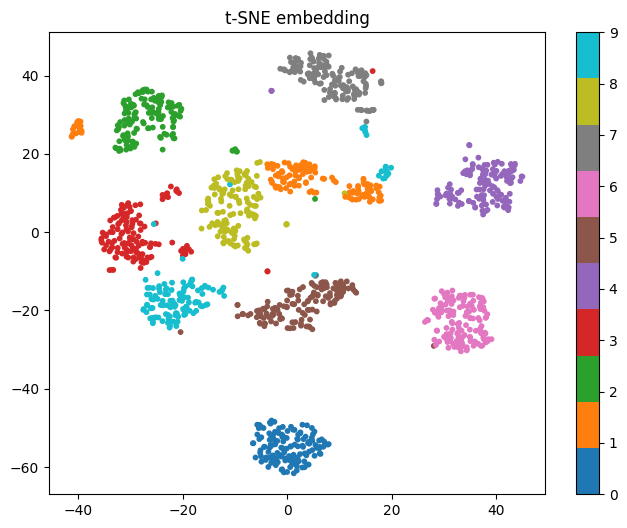

In [20]:
tsne = TSNE(
    n_components=2,
    random_state=42
)

X_tsne = tsne.fit_transform(X_train)

plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=y_train,
    cmap="tab10",
    s=10
)

plt.colorbar(scatter)
plt.title("t-SNE embedding")
plt.show()

Metoda t-SNE nie implementuje transformacji nowych obserwacji. Oznacza to, że po dopasowaniu modelu do zbioru treningowego nie można w prosty sposób przekształcić zbioru testowego. Jest to przede wszystkim narzędzie wizualizacyjne.

In [21]:
comparison = {
    "UMAP": accuracy_score(y_test, pred_umap),
    "PaCMAP": accuracy_score(y_test, pred_pacmap),
}

for method, score in comparison.items():
    print(f"{method}: {score:.4f}")

UMAP: 0.9778
PaCMAP: 0.9622


Przeprowadzone eksperymenty pokazują, że nieliniowe metody redukcji wymiarowości mogą być skuteczne w zadaniu klasyfikacji cyfr. Model wykorzystujący reprezentację uzyskaną za pomocą UMAP osiągnął dokładność 97,78%, natomiast dla PaCMAP uzyskano 96,22%.

Wysokie wyniki wskazują, że obie metody dobrze zachowują strukturę danych i umożliwiają skuteczne rozróżnianie poszczególnych klas cyfr. Szczególnie UMAP pozwolił uzyskać rezultat porównywalny z najlepszymi metodami analizowanymi wcześniej.

Jednocześnie należy zauważyć, że zbiór `digits` zawiera jedynie 64 cechy wejściowe, a klasyczne metody redukcji wymiarowości, takie jak PCA, również osiągają bardzo dobre wyniki przy znacznie mniejszym koszcie obliczeniowym. Zaawansowane techniki nieliniowe wymagają więcej czasu obliczeń i są trudniejsze w interpretacji.

W analizowanym problemie zastosowanie metod takich jak UMAP i PaCMAP jest uzasadnione i prowadzi do bardzo dobrej jakości klasyfikacji, jednak uzyskana poprawa względem prostszych metod może nie rekompensować zwiększonej złożoności obliczeniowej. Metody te wydają się szczególnie przydatne w bardziej złożonych zbiorach danych, gdzie zależności między cechami mają charakter nieliniowy.